# 04-2. 확률적 경사 하강법

생선의 무게·길이·대각선 길이·높이·두께로 7개 어종을 분류하면서, `SGDClassifier`, `partial_fit()`, 에포크별 학습 곡선과 손실 함수 차이를 확인한다.

## 학습 목표

- 확률적 경사 하강법과 점진적 학습의 의미 이해
- `fit()`과 `partial_fit()`의 차이 확인
- 에포크별 훈련·테스트 정확도로 과대적합과 과소적합 판단
- `log_loss`와 `hinge` 결과 비교

## 1. 데이터 준비

이 실습은 `Species`라는 정답이 있는 **다중 분류 지도 학습**이다.

> **이전 질문과 연결 — “회귀는 지도 학습이고 분류는 비지도 학습인가?”**  
> 회귀와 분류는 모두 정답이 있으면 지도 학습이다. 여기서는 `fish_target`에 어종 이름이 있으므로 지도 학습 분류 문제다.

In [1]:
import pandas as pd

# 04-1과 동일한 생선 데이터를 DataFrame으로 불러온다.
# 7개 어종을 분류하는 지도 학습 실습에 사용한다.
fish = pd.read_csv('http://bit.ly/fish_csv_data')

In [3]:
# 모델이 참고할 수치형 특성 5개를 입력 데이터로 선택한다.
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']]

# 모델이 맞혀야 할 어종 이름을 타깃으로 선택한다.
fish_target = fish['Species']

In [18]:
from sklearn.model_selection import train_test_split

# 전체 데이터를 훈련 세트와 테스트 세트로 나눈다.
# random_state=42는 실행할 때마다 같은 분할을 재현하기 위한 값이다.
train_input, test_input, train_target, test_target = train_test_split(
    fish_input,
    fish_target,
    random_state=42
)

## 2. 특성 표준화

확률적 경사 하강법은 특성값으로 계산한 기울기를 따라 계수를 갱신한다. 특성 범위가 크게 다르면 `Weight`처럼 값이 큰 특성이 갱신 방향을 지나치게 좌우할 수 있으므로 평균 0, 표준편차 1 기준으로 맞춘다.

> **이전 질문과 연결 — “표준화하면 값이 왜 변하고, 결정 트리는 왜 필요 없나?”**  
> 표준화는 샘플 자체를 바꾸는 것이 아니라 좌표의 단위를 바꾼다. 경사 하강법은 값의 크기에 영향을 받으므로 표준화가 중요하지만, 결정 트리는 값의 순서와 분할 기준을 사용하므로 같은 비율로 스케일을 바꿔도 분할 구조가 거의 변하지 않는다.

In [19]:
from sklearn.preprocessing import StandardScaler

# 훈련 세트에서 특성별 평균과 표준편차를 계산한다.
ss = StandardScaler()
ss.fit(train_input)

# 훈련 세트와 테스트 세트에 같은 기준을 적용한다.
# 테스트 세트에는 다시 fit()하지 않아 데이터 누수를 막는다.
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

## 3. `SGDClassifier`로 첫 학습

확률적 경사 하강법은 훈련 샘플을 차례로 사용해 손실이 작아지는 방향으로 모델 계수를 조금씩 수정한다.

- **확률적 경사 하강법**: 샘플 1개씩 갱신
- **미니배치 경사 하강법**: 일부 샘플 묶음으로 갱신
- **배치 경사 하강법**: 전체 샘플로 한 번에 갱신

In [20]:
# 확률적 경사 하강법으로 선형 분류 모델을 학습하는 클래스
from sklearn.linear_model import SGDClassifier

In [21]:
# log_loss는 로지스틱 회귀와 같은 분류 손실 함수이다.
# max_iter=10은 훈련 세트를 최대 10번 반복한다는 뜻이다.
sc = SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
sc.fit(train_scaled, train_target)

# 훈련 정확도와 테스트 정확도를 비교한다.
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.773109243697479
0.775


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


`max_iter=10`에서 훈련 정확도 `0.7731`, 테스트 정확도 `0.7750`이 나왔고 수렴 경고가 발생했다. 이는 오류가 아니라, 정해 둔 10에포크 안에 최적화가 충분히 끝나지 않았다는 뜻이다.

## 4. `partial_fit()`과 점진적 학습

`partial_fit()`은 이전에 학습한 계수를 유지한 채 추가 학습한다. 새 데이터가 조금씩 들어오는 상황에서 전체 데이터를 처음부터 다시 학습하지 않고 모델을 갱신할 수 있다.

In [22]:
# 기존에 학습한 가중치를 유지한 채 훈련을 한 번 더 진행한다.
# fit()과 달리 모델을 처음부터 다시 만들지 않는다.
sc.partial_fit(train_scaled, train_target)

print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.7983193277310925
0.775


한 번 추가 학습한 뒤 훈련 정확도는 `0.7983`으로 상승했고 테스트 정확도는 `0.7750`으로 유지됐다. 한 번의 추가 학습만으로 일반화 성능이 반드시 좋아지는 것은 아니므로 에포크별 변화를 함께 봐야 한다.

## 5. 에포크별 훈련·테스트 정확도

In [23]:
import numpy as np

# 에포크별 정확도 변화를 확인하기 위해 새 모델을 만든다.
sc = SGDClassifier(loss='log_loss', random_state=42)
train_score = []
test_score = []

# 첫 partial_fit() 호출에는 가능한 전체 클래스 목록을 알려 줘야 한다.
classes = np.unique(train_target)

In [25]:
# partial_fit()을 300번 호출하며 에포크별 정확도를 기록한다.
# 이 코드에서는 매번 전체 훈련 세트를 전달하므로 한 호출이 한 에포크에 해당한다.
for epoch in range(300):
    sc.partial_fit(train_scaled, train_target, classes=classes)
    train_score.append(sc.score(train_scaled, train_target))
    test_score.append(sc.score(test_scaled, test_target))

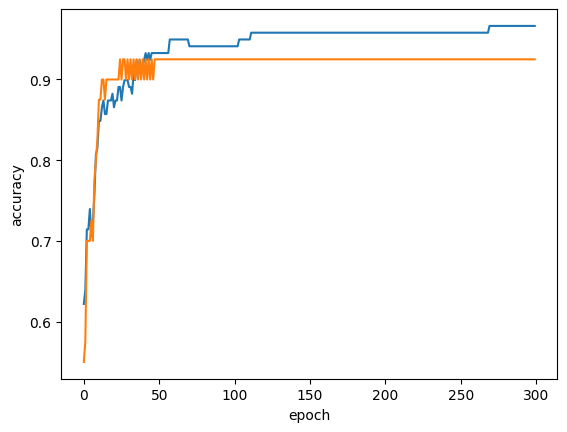

In [26]:
import matplotlib.pyplot as plt

# 리스트의 인덱스가 에포크 순서이며, 두 정확도의 변화를 함께 그린다.
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

![에포크별 훈련·테스트 정확도](assets/01_epoch_accuracy_curve.png)

파란색은 훈련 정확도, 주황색은 테스트 정확도다. 초반에는 둘 다 상승하지만 약 50~100에포크 이후 테스트 정확도는 거의 `0.925`에 머무르고 훈련 정확도만 조금씩 높아진다. 더 오래 학습해도 테스트 성능이 좋아지지 않는 구간이다.

> **이전 질문과 연결 — “훈련 0.96, 테스트 0.99면 과소적합이지만 테스트가 높으니 수정할 필요 없는가?”**  
> 테스트 점수가 훈련 점수보다 조금 높다는 사실만으로 과소적합이라고 단정하지 않는다. 분할된 샘플의 난이도 차이로 테스트 점수가 더 높을 수 있다. 두 점수의 절대 수준과 학습 곡선을 함께 보고, 둘 다 낮으면 과소적합, 훈련만 계속 높아지고 테스트가 정체되면 과대적합으로 판단한다.

## 6. 100에포크로 최종 학습

그래프를 참고해 반복 횟수를 100으로 고정한다. `tol=None`은 검증된 개선 폭에 따른 자동 조기 종료를 사용하지 않고 지정한 횟수만큼 학습하게 한다.

In [27]:
# tol=None으로 조기 종료를 끄고 정확히 100에포크를 학습한다.
sc = SGDClassifier(
    loss='log_loss',
    max_iter=100,
    tol=None,
    random_state=42
)
sc.fit(train_scaled, train_target)

print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.957983193277311
0.925


최종 `log_loss` 모델은 훈련 정확도 `0.9580`, 테스트 정확도 `0.9250`을 기록했다. 훈련 점수가 더 높지만 차이가 지나치게 크지는 않으며, 10에포크 모델보다 테스트 성능이 크게 개선됐다.

## 7. `log_loss`와 `hinge` 비교

- `log_loss`: 로지스틱 회귀 손실. 클래스 확률을 다루는 분류에 적합
- `hinge`: 선형 SVM 손실. 정답 클래스를 결정 경계에서 충분히 멀리 보내는 방향으로 학습

In [28]:
# hinge는 선형 서포트 벡터 머신에서 사용하는 손실 함수이다.
# 같은 데이터와 반복 횟수에서 log_loss와 정확도를 비교한다.
sc = SGDClassifier(
    loss='hinge',
    max_iter=100,
    tol=None,
    random_state=42
)
sc.fit(train_scaled, train_target)

print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.9495798319327731
0.925


| 손실 함수 | 훈련 정확도 | 테스트 정확도 |
|---|---:|---:|
| `log_loss` | `0.9580` | `0.9250` |
| `hinge` | `0.9496` | `0.9250` |

이 실습에서는 테스트 정확도가 같았다. 따라서 정확도만으로 우열을 단정하기보다, 확률 출력 필요 여부와 모델 목적을 함께 봐야 한다.

## 정리

```text
데이터 분리와 표준화
→ SGDClassifier로 짧게 학습
→ partial_fit으로 점진적 학습
→ 에포크별 훈련·테스트 정확도 확인
→ 100에포크로 고정
→ log_loss와 hinge 비교
```

핵심은 **에포크를 무조건 늘리는 것이 아니라 테스트 성능이 더 이상 좋아지지 않는 시점을 확인하는 것**이다.